In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.linear_model import LinearRegression
import mglearn
from sklearn.model_selection import train_test_split
X, y = mglearn.datasets.make_wave(n_samples=60)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
lr = LinearRegression().fit(X_train, y_train)

In [3]:
print("lr.coef_: {}".format(lr.coef_))
print("lr.intercept_: {}".format(lr.intercept_))

lr.coef_: [0.39390555]
lr.intercept_: -0.031804343026759746


In [4]:
print("Training set score: {:.2f}".format(lr.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lr.score(X_test, y_test)))

Training set score: 0.67
Test set score: 0.66


In [5]:
X, y = mglearn.datasets.load_extended_boston()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10)
lr = LinearRegression().fit(X_train, y_train)

In [6]:
X_train

array([[2.01636779e-02, 0.00000000e+00, 7.00879765e-01, ...,
        3.28472519e-01, 1.64631169e-01, 8.25135137e-02],
       [4.44757259e-03, 0.00000000e+00, 3.46041056e-01, ...,
        9.91495289e-01, 2.37119862e-01, 5.67081153e-02],
       [7.00012184e-04, 0.00000000e+00, 8.90762463e-02, ...,
        1.00000000e+00, 1.23068433e-01, 1.51458391e-02],
       ...,
       [2.66635180e-02, 0.00000000e+00, 6.46627566e-01, ...,
        8.72376160e-01, 2.99223656e-01, 1.02633245e-01],
       [1.82870877e-03, 0.00000000e+00, 9.23387097e-01, ...,
        9.40985120e-01, 3.50115173e-01, 1.30268409e-01],
       [8.48938989e-03, 2.00000000e-01, 1.28665689e-01, ...,
        9.77434721e-01, 2.37887804e-01, 5.78970708e-02]])

In [7]:
print("Training set score: {:.2f}".format(lr.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lr.score(X_test, y_test)))

Training set score: 0.93
Test set score: 0.88


In [8]:
lr.score(X_train, y_train)

0.9318236158880049

In [9]:
"Training set score: {:.3f}".format(lr.score(X_train, y_train))

'Training set score: 0.932'

In [10]:
"Test set score: {:.2f}".format(lr.score(X_test,y_test))

'Test set score: 0.88'

In [11]:
from sklearn.linear_model import Ridge
ridge = Ridge().fit(X_train, y_train)
print("Training set score: {:.2f}".format(ridge.score(X_train, y_train)))
print("Test set score: {:.2f}".format(ridge.score(X_test, y_test)))

Training set score: 0.85
Test set score: 0.82


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
pred = ridge.predict(X_test)

In [14]:
sorted_idx = np.argsort(X_test[:, 0])

In [15]:
X_test_sorted = X_test[sorted_idx]
X_test_sorted

array([[7.51939870e-05, 3.50000000e-01, 3.88563050e-02, ...,
        9.89136529e-01, 1.03187663e-01, 1.07646351e-02],
       [9.07048543e-05, 6.00000000e-01, 9.05425220e-02, ...,
        9.00723428e-01, 6.93990323e-02, 5.34706385e-03],
       [1.39148215e-04, 8.50000000e-01, 1.35263930e-01, ...,
        9.77584303e-01, 1.26319359e-01, 1.63224597e-02],
       ...,
       [2.25678398e-01, 0.00000000e+00, 6.46627566e-01, ...,
        5.18299788e-01, 5.74116686e-01, 6.35944634e-01],
       [2.65729031e-01, 0.00000000e+00, 6.46627566e-01, ...,
        1.00000000e+00, 6.05960265e-01, 3.67187843e-01],
       [5.14104099e-01, 0.00000000e+00, 6.46627566e-01, ...,
        4.91824400e-02, 2.15712826e-01, 9.46110505e-01]])

In [16]:
y_pred_sorted = pred[sorted_idx]

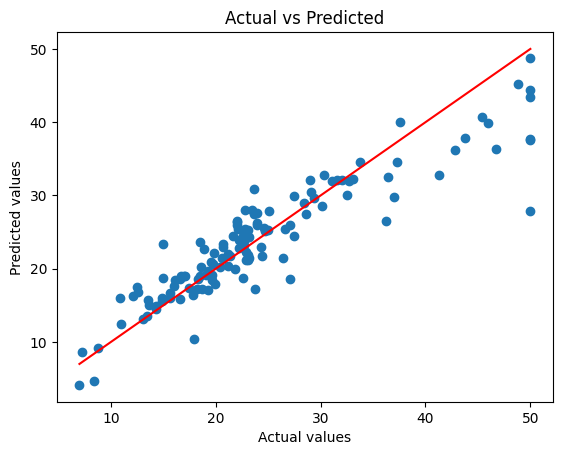

In [17]:
y_pred = ridge.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')  # perfect prediction line
plt.show()

In [18]:
ridge10 = Ridge(alpha=0).fit(X_train, y_train)
print("Training set score: {:.2f}".format(ridge10.score(X_train, y_train)))
print("Test set score: {:.2f}".format(ridge10.score(X_test, y_test)))

Training set score: 0.93
Test set score: 0.88


c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.07206e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


### Ridge regularization analysis
We now compare Ridge models across several regularization strengths and inspect how training/test performance and coefficient magnitude change with `alpha`.

c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.07206e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


alpha  train R^2  test R^2  train MSE  test MSE
0      0.932      0.878      5.309      12.134
0.1    0.903      0.874      7.560      12.512
1      0.854      0.824      11.371      17.511
10     0.762      0.691      18.542      30.781
100    0.562      0.443      34.118      55.542


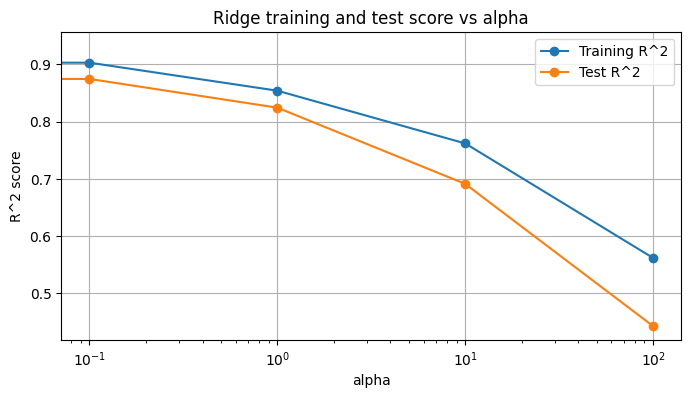

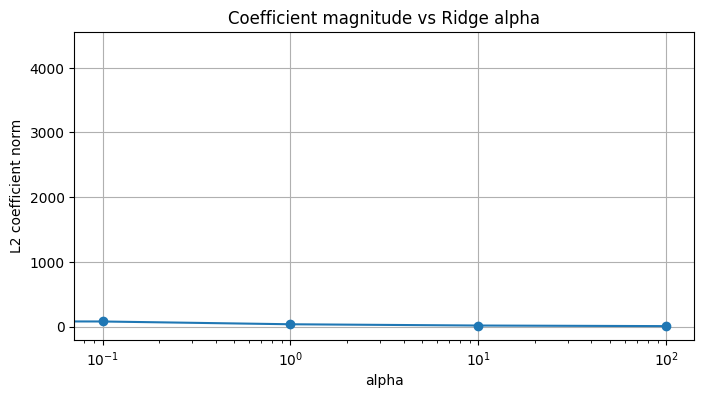

In [19]:
from sklearn.metrics import mean_squared_error

alphas = [0, 0.1, 1, 10, 100]
train_scores = []
test_scores = []
train_mse = []
test_mse = []
coef_norms = []

for alpha in alphas:
    model = Ridge(alpha=alpha).fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))
    train_mse.append(mean_squared_error(y_train, train_pred))
    test_mse.append(mean_squared_error(y_test, test_pred))
    coef_norms.append(np.linalg.norm(model.coef_))

print("alpha  train R^2  test R^2  train MSE  test MSE")
for alpha, tr, te, tm, tsm in zip(alphas, train_scores, test_scores, train_mse, test_mse):
    print(f"{alpha:<5}  {tr:.3f}      {te:.3f}      {tm:.3f}      {tsm:.3f}")

plt.figure(figsize=(8, 4))
plt.semilogx(alphas, train_scores, marker='o', label='Training R^2')
plt.semilogx(alphas, test_scores, marker='o', label='Test R^2')
plt.xlabel('alpha')
plt.ylabel('R^2 score')
plt.title('Ridge training and test score vs alpha')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.semilogx(alphas, coef_norms, marker='o')
plt.xlabel('alpha')
plt.ylabel('L2 coefficient norm')
plt.title('Coefficient magnitude vs Ridge alpha')
plt.grid(True)
plt.show()

### Conclusion
The comparison shows how increasing `alpha` reduces coefficient magnitude and generally lowers training performance while often improving or stabilizing test performance. In practice, choose the smallest `alpha` that prevents overfitting and produces stable generalization on unseen data.